In [8]:
import sys
!{sys.executable} -m pip install xgboost   

In [9]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge 
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv("C:\\Users\\Admin\\Downloads\\nairobi_real_estate.csv")
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Neighborhood     1000 non-null   object 
 1   PropertyType     1000 non-null   object 
 2   Bedrooms         1000 non-null   int64  
 3   Bathrooms        1000 non-null   int64  
 4   SizesqFt         1000 non-null   int64  
 5   ParkingSpaces    1000 non-null   int64  
 6   AgeYears         980 non-null    float64
 7   DistanceCBD_km   980 non-null    float64
 8   HasPool          1000 non-null   int64  
 9   HasGarden        1000 non-null   int64  
 10  HasBorehole      1000 non-null   int64  
 11  HasGenerator     1000 non-null   int64  
 12  IsGated          1000 non-null   int64  
 13  ServantQuarters  1000 non-null   int64  
 14  Price_KES        1000 non-null   float64
dtypes: float64(3), int64(10), object(2)
memory usage: 117.3+ KB


,Bedrooms,Bathrooms,SizesqFt,ParkingSpaces,AgeYears,DistanceCBD_km,HasPool,HasGarden,HasBorehole,HasGenerator,IsGated,ServantQuarters,Price_KES
count,1000.000000,1000.000000,1000.000000,1000.000000,980.000000,980.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,3.133000,2.765000,1625.334000,1.905000,14.418367,11.360306,0.221000,0.590000,0.435000,0.513000,0.704000,0.542000,1.829822e+07
std,1.330068,1.337746,702.757301,0.950199,8.712668,4.368216,0.415128,0.492079,0.496005,0.500081,0.456719,0.498482,1.049662e+07
min,1.000000,1.000000,400.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000e+06
25%,2.000000,2.000000,1084.000000,1.000000,7.000000,8.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.946500e+06
50%,3.000000,3.000000,1594.500000,2.000000,15.000000,10.550000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.595500e+07
75%,4.000000,4.000000,2085.500000,3.000000,22.000000,14.100000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.478325e+07
max,6.000000,6.000000,3600.000000,4.000000,29.000000,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.285000e+07


In [10]:
df.isnull().sum()

Neighborhood        0
PropertyType        0
Bedrooms            0
Bathrooms           0
SizesqFt            0
ParkingSpaces       0
AgeYears           20
DistanceCBD_km     20
HasPool             0
HasGarden           0
HasBorehole         0
HasGenerator        0
IsGated             0
ServantQuarters     0
Price_KES           0
dtype: int64

In [11]:
df.fillna(df.select_dtypes(include='number').mean(), inplace=True)
df.isnull().sum()

Neighborhood       0
PropertyType       0
Bedrooms           0
Bathrooms          0
SizesqFt           0
ParkingSpaces      0
AgeYears           0
DistanceCBD_km     0
HasPool            0
HasGarden          0
HasBorehole        0
HasGenerator       0
IsGated            0
ServantQuarters    0
Price_KES          0
dtype: int64

In [12]:
df = pd.get_dummies(df, columns = ['Neighborhood', 'PropertyType'], drop_first=True)
print("Shape after encoding:", df.shape)
print(df.head())

Shape after encoding: (1000, 31)
   Bedrooms  Bathrooms  SizesqFt  ParkingSpaces  AgeYears  DistanceCBD_km  \
0         2          2      1191              2       4.0             7.0   
1         3          3      1378              3      16.0            13.7   
2         5          4      2441              2      19.0            10.4   
3         4          4      1792              3       0.0            13.6   
4         4          4      2460              2      21.0            18.0   

   HasPool  HasGarden  HasBorehole  HasGenerator  ...  Neighborhood_Muthaiga  \
0        0          0            1             0  ...                  False   
1        1          0            1             0  ...                  False   
2        0          0            0             1  ...                  False   
3        1          1            0             1  ...                  False   
4        1          1            0             0  ...                  False   

   Neighborhood_Ruaka  

In [13]:
from sklearn.model_selection import train_test_split
X = df.drop('Price_KES', axis=1)
y = df['Price_KES']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear Regression RMSE: KES {rmse_lr:.2f}")

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print(f"Ridge Regression RMSE: KES {rmse_ridge:.2f}")

# XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, subsample=0.7, colsample_bytree=0.7, reg_alpha=10, reg_lambda=10, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)   
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"XGBoost RMSE: KES {rmse_xgb:.2f}")

#Comparison
print("\nModel Comparison:")
print(f"Linear Regression RMSE: KES {rmse_lr:.2f}")
print(f"Ridge Regression RMSE: KES {rmse_ridge:.2f}")
print(f"XGBoost RMSE: KES {rmse_xgb:.2f}")

Linear Regression RMSE: KES 2768298.45
Ridge Regression RMSE: KES 2789857.75
XGBoost RMSE: KES 3528147.50

Model Comparison:
Linear Regression RMSE: KES 2768298.45
Ridge Regression RMSE: KES 2789857.75
XGBoost RMSE: KES 3528147.50


In [14]:
# Check training vs test RMSE for each model
train_pred_lr = lr.predict(X_train)
train_rmse_lr = np.sqrt(mean_squared_error(y_train, train_pred_lr))

train_pred_xgb = xgb.predict(X_train)
train_rmse_xgb = np.sqrt(mean_squared_error(y_train, train_pred_xgb))

print(" Training vs Test RMSE ")
print(f"Linear Regression - Train: KES {train_rmse_lr:,.0f} | Test: KES {rmse_lr:,.0f}")
print(f"XGBoost           - Train: KES {train_rmse_xgb:,.0f} | Test: KES {rmse_xgb:,.0f}")

 Training vs Test RMSE 
Linear Regression - Train: KES 2,492,154 | Test: KES 2,768,298
XGBoost           - Train: KES 2,700,831 | Test: KES 3,528,147


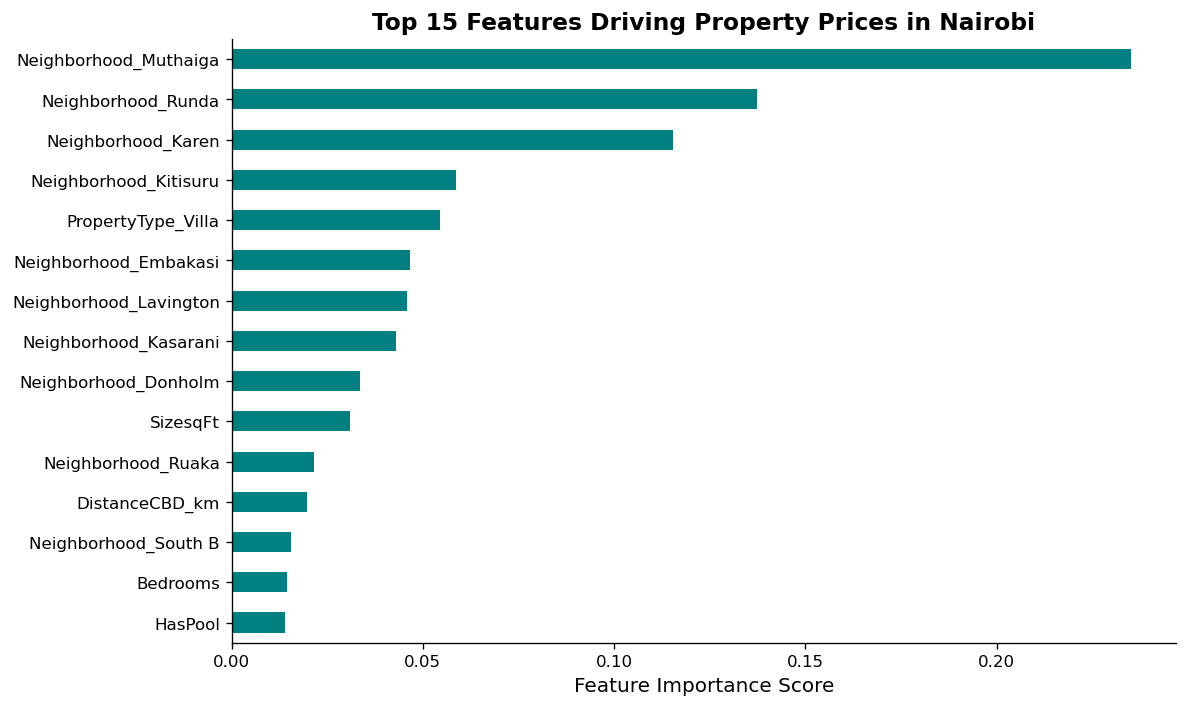


Top 10 most important features influencing property prices in Nairobi:
Neighborhood_Muthaiga     0.2351
Neighborhood_Runda        0.1373
Neighborhood_Karen        0.1154
Neighborhood_Kitisuru     0.0588
PropertyType_Villa        0.0544
Neighborhood_Embakasi     0.0467
Neighborhood_Lavington    0.0460
Neighborhood_Kasarani     0.0429
Neighborhood_Donholm      0.0335
SizesqFt                  0.0309
dtype: float32


In [15]:
#Feature importance from XGBoost
importances = pd.Series(xgb.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Features Driving Property Prices in Nairobi', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 10 most important features influencing property prices in Nairobi:")
print(top_features.head(10).round(4))

## Feature Importance
Location is the dominant price driver in Nairobi real estate.
Muthaiga, Runda and Karen alone account for nearly 50% of the 
model's predictive power. Physical features like size, bedrooms 
and amenities play a secondary role. This confirms the Nairobi 
real estate mantra: location, location, location.

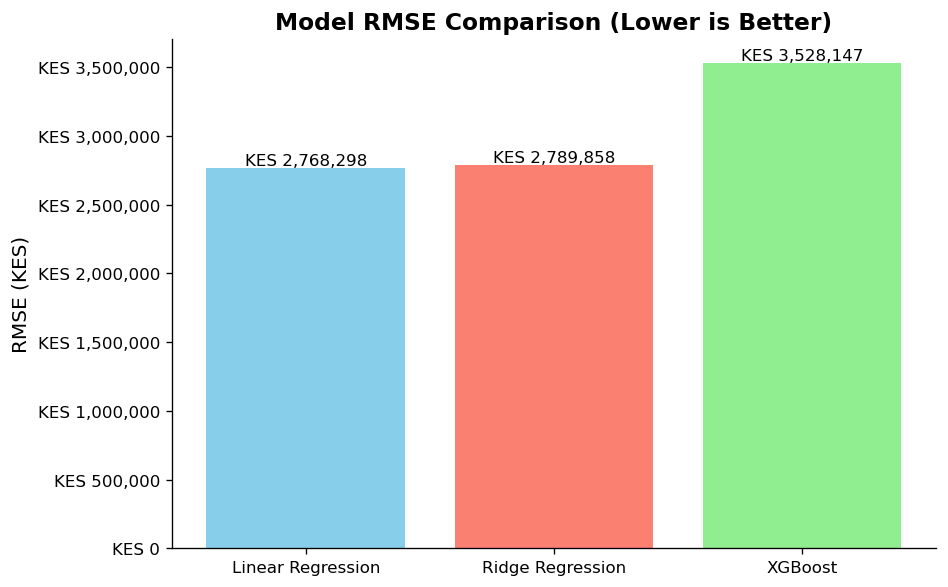

In [16]:
models = ['Linear Regression', 'Ridge Regression', 'XGBoost']
rmse_scores = [rmse_lr, rmse_ridge, rmse_xgb]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, rmse_scores, color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Model RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
plt.ylabel('RMSE (KES)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'KES {x:,.0f}'))

for bar, score in zip(bars, rmse_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'KES {score:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()